In [1]:
import pandas as pd
import numpy as np

import networkx as nx

import matplotlib.pyplot as plt

from pathlib import Path

import sys

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [2]:
DATA_DIR = Path(
    "../data/raw/elliptic/elliptic_bitcoin_dataset"
)

FEATURES_PATH = (
    DATA_DIR /
    "elliptic_txs_features.csv"
)

CLASSES_PATH = (
    DATA_DIR /
    "elliptic_txs_classes.csv"
)

EDGES_PATH = (
    DATA_DIR /
    "elliptic_txs_edgelist.csv"
)

features_df = pd.read_csv(
    FEATURES_PATH,
    header=None
)

classes_df = pd.read_csv(
    CLASSES_PATH
)

edges_df = pd.read_csv(
    EDGES_PATH
)

In [3]:
print("Feature Shape:")
print(features_df.shape)
print("\n classes Shape:")
print(classes_df.shape)
print("Edges Shape:")
print(edges_df.shape)

Feature Shape:
(203769, 167)

 classes Shape:
(203769, 2)
Edges Shape:
(234355, 2)


In [4]:
features_df.head()

,0,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [5]:
feature_columns = [
    "txId",
    "time_step"
]

for i in range(
    features_df.shape[1] - 2
):

    feature_columns.append(
        f"feature_{i}"
    )

features_df.columns = (
    feature_columns
)

In [6]:
features_df.head()

,txId,time_step,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_155,feature_156,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [7]:
classes_df.head()

,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


In [8]:
classes_df["class"].value_counts()

class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64

In [9]:
classes_df = classes_df[classes_df["class"]!= "unknown"]

In [10]:
classes_df["class"].value_counts()

class
2    42019
1     4545
Name: count, dtype: int64

In [11]:
classes_df["class"] = (
    classes_df["class"]
    .astype(int)
)

In [12]:
classes_df["class"] = (
    classes_df["class"]
    .map({
        1: 1,
        2: 0
    })
)

In [13]:
classes_df["class"].value_counts()

class
0    42019
1     4545
Name: count, dtype: int64

In [14]:
edges_df.head()

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [15]:
print("Number of Nodes:")
print(len(features_df))

print("\nNumber of Edges:")
print(len(edges_df))

print("\nFraud Distribution:")
print(
    classes_df["class"]
    .value_counts()
)

Number of Nodes:
203769

Number of Edges:
234355

Fraud Distribution:
class
0    42019
1     4545
Name: count, dtype: int64


In [16]:
sample_edges = edges_df.head(
    500
)

G = nx.from_pandas_edgelist(
    sample_edges,
    source="txId1",
    target="txId2"
)

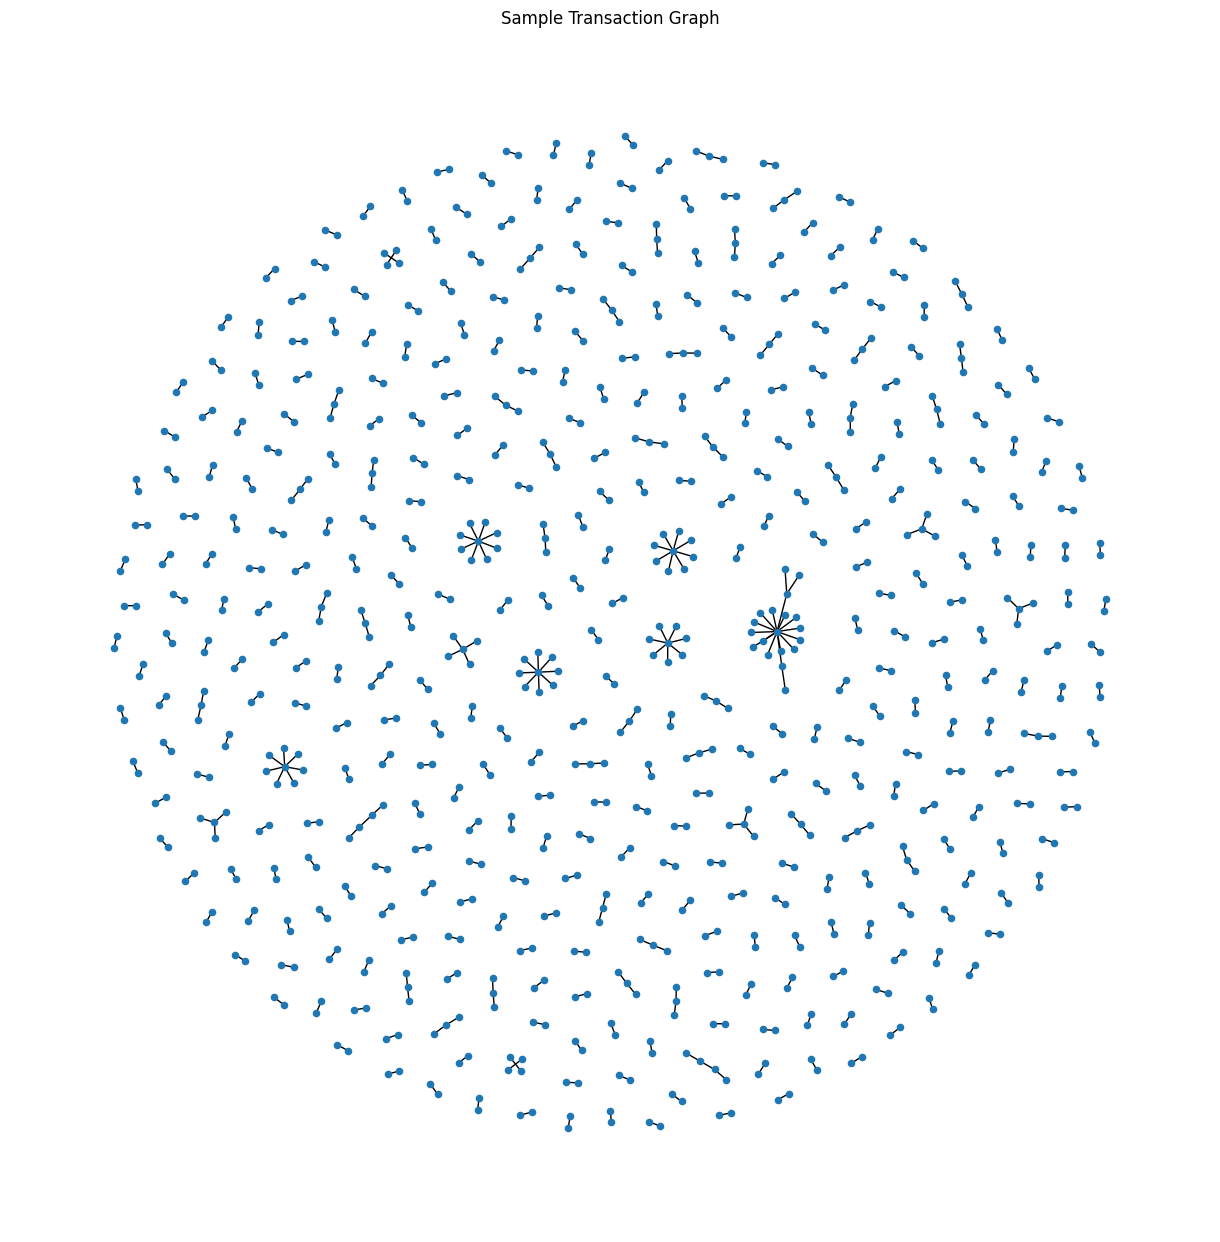

In [17]:
plt.figure(figsize=(12, 12))

nx.draw(
    G,
    node_size=20,
    with_labels=False
)

plt.title(
    "Sample Transaction Graph"
)

plt.show()

In [18]:
degrees = [
    degree
    for node, degree
    in G.degree()
]

print(
    "Average Degree:"
)

print(
    np.mean(degrees)
)

Average Degree:
1.1185682326621924


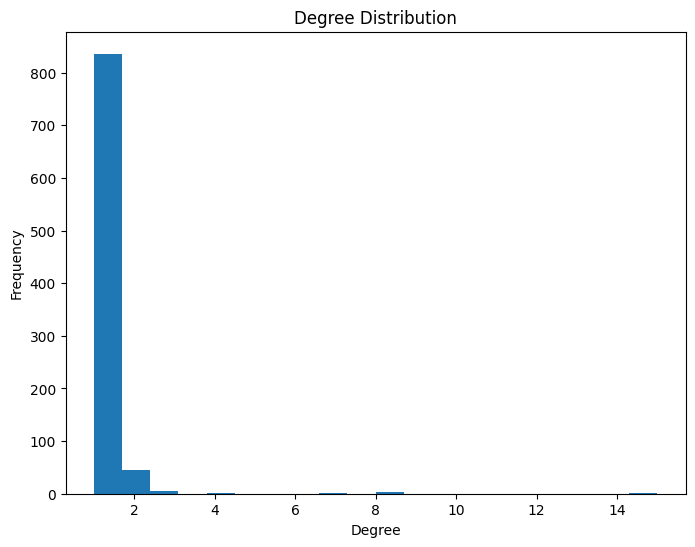

In [19]:
plt.figure(figsize=(8, 6))

plt.hist(
    degrees,
    bins=20
)

plt.xlabel("Degree")

plt.ylabel("Frequency")

plt.title(
    "Degree Distribution"
)

plt.show()

In [20]:
merged_df = features_df.merge(
    classes_df,
    on="txId"
)

In [21]:
merged_df.head()

,txId,time_step,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_156,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,class
0,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,0
1,232029206,1,-0.005027,0.578941,-0.091383,4.380281,-0.063725,4.667146,0.851305,-0.163645,...,-0.613614,0.241128,0.241406,0.604120,0.008632,-0.131155,0.333211,-0.120613,-0.119792,0
2,232344069,1,-0.147852,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.137933,...,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,0
3,27553029,1,-0.151357,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.141519,...,-0.582077,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,0
4,3881097,1,-0.172306,-0.184668,-1.201369,0.028105,-0.043875,-0.029140,0.242712,-0.163640,...,-0.600999,0.241128,0.241406,0.018279,-0.068266,-0.084674,-0.054450,-1.760926,-1.760984,0


In [ ]:

from src.gnn.data.build_graph_dataset import build_graph_dataset
data = build_graph_dataset()

print("\nGraph Data Object")
print("=" * 50)

print(data)

print("\nNode Features Shape:")
print(data.x.shape)

print("\nEdge Index Shape:")
print(data.edge_index.shape)

print("\nLabels Shape:")
print(data.y.shape)
print(data.train_mask.sum())

print(data.val_mask.sum())

print(data.test_mask.sum())



Graph Data Object
Data(x=[46564, 166], edge_index=[2, 36624], y=[46564], train_mask=[46564], val_mask=[46564], test_mask=[46564])

Node Features Shape:
torch.Size([46564, 166])

Edge Index Shape:
torch.Size([2, 36624])

Labels Shape:
torch.Size([46564])
tensor(33525)
tensor(3726)
tensor(9313)


In [25]:
import torch

print(torch.backends.mps.is_available())


True
